# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="002"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "PCA_nebula"
# adta that contins both H and D (with perturbations) BUT without depletion
ADATA_HEALTHY = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/depleted_dorsal_matrix/depleted_dorsal_matrix_healthy.h5ad"
SAVE_HEALTHY_PCA_RESULT = f"{os.path.split(ADATA_HEALTHY)[0]}/PCA_healthy"

N_PCS_TO_USE = 6  # CHANGE THIS BASED ON YOUR ELBOW PLOT


# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Calculate PCs for Healhty

PCs:
- same ofr all healthy
- for diseased: same for the one in the same geneset (% depletions doenst change the projectiosn)

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.h5ad
Normalising
Scaling
PCA on Diseased


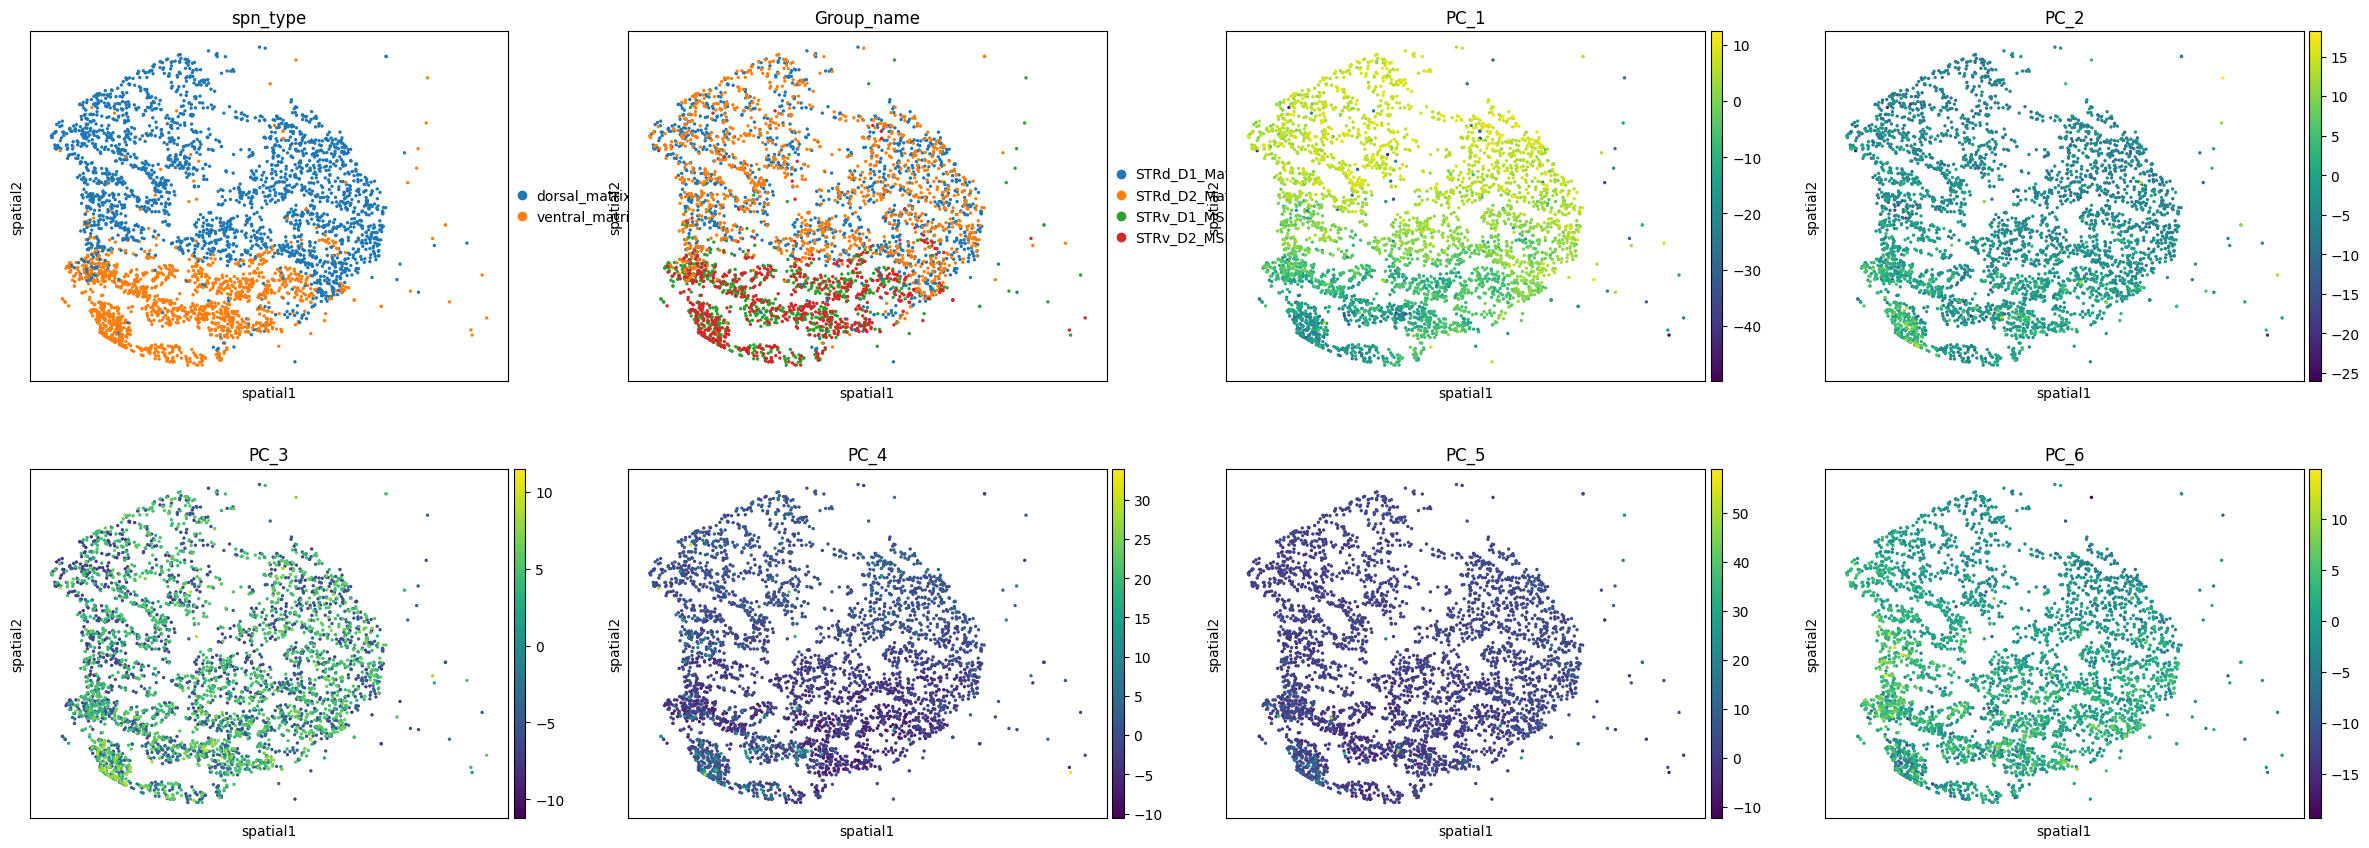

Done.


In [2]:
def calculate_pca(adata, calculate_or_project, saving_folder, N_PCS_TO_USE=None, df_stats=None, df_loadings=None):
    
    # Common steps
    print("Normalising")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    if calculate_or_project == "calculate":
        # Find highly variable genes on HEALTHY only
        print("HVG")
        sc.pp.highly_variable_genes(adata, n_top_genes=3000)
        hvg = adata.var_names[adata.var['highly_variable']].tolist()  # Get as ordered list
        adata = adata[:, hvg].copy() # Subset with 01 Index
    elif calculate_or_project == "project":
        hvg = df_loadings.index.tolist()
        # Subset and REORDER to match loadings
        adata = adata[:, hvg].copy() # Subset wiht gene names
        assert all(adata.var_names == df_loadings.index), "Gene order mismatch!"

    # Ectarct dense matrix
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X

    # Scale using healthy statistics
    print("Scaling")
    if calculate_or_project == "calculate":
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_scaled = scaler.fit_transform(X)

        mean_train = scaler.mean_
        var_train = scaler.var_

        df_stats = pd.DataFrame({
            "mean_train": mean_train,
            "var_train": var_train
        }, index=adata.var_names)
        df_stats.to_csv(f"{saving_folder}/healthy_stats.csv")
        
    elif calculate_or_project == "project":
        df_stats = df_stats.reindex(adata.var_names) # FORCE SAME ORDER
        mean_train = df_stats["mean_train"].values
        var_train = df_stats["var_train"].values

        X_scaled = (X - mean_train) / np.sqrt(var_train)


    # PCA 
    MAX_PCS_TO_COMPUTE = 50
    if calculate_or_project == "calculate":
        print("PCA on Healthy")
        pca = PCA(n_components=MAX_PCS_TO_COMPUTE, random_state=42, svd_solver="full")
        pcs = pca.fit_transform(X_scaled)

        # Save pcs
        df_healthy = pd.DataFrame(
            pcs[:, :N_PCS_TO_USE],
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_healthy.insert(0, 'barcode', adata.obs_names.values)
        df_healthy.to_csv(f"{saving_folder}/healthy_pcs.csv", index=False)

        # Extract loadings (genes × PCs)
        loadings = pca.components_.T  # Shape: (n_genes, n_components)
        # save loadings
        df_loadings = pd.DataFrame(
            loadings,
            index= adata.var_names,
            columns=[f'PC_{i+1}' for i in range(loadings.shape[1])]
        )
        df_loadings.to_csv(f"{saving_folder}/gene_loadings.csv")

    elif calculate_or_project == "project":
        print("PCA on Diseased")
        loadings = df_loadings.values
        pcs = X_scaled @ loadings  # apply ppject wiht laodings
        # save pcs
        df_diseased = pd.DataFrame(
            pcs[:, :N_PCS_TO_USE],
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_diseased.insert(0, 'barcode', adata.obs_names.values)
        df_diseased.to_csv(f"{saving_folder}/diseased_pcs.csv", index=False)


    # Plot PCs of a fingle sample
    sample_id = adata.obs[SAMPLE_VARIABLE].unique()[0]
    adata_s = adata[adata.obs[SAMPLE_VARIABLE] == sample_id].to_memory().copy()
    adata_s.obs = adata_s.obs.drop(columns=[c for c in adata_s.obs.columns if "PC_" in c])
    adata_s.obs = adata_s.obs.merge(
        df_healthy if calculate_or_project == "calculate" else df_diseased,
        left_index=True,
        right_on="barcode",
        how="left", 
        validate="one_to_one"
    )
    adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    sc.pl.embedding(adata_s, basis="spatial", color=["spn_type", "Group_name", *pcs])
    del adata_s

    # SAVE PCS + DIAGBOSTICS
    if calculate_or_project == "calculate":

        # Elbow plot
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_, 'o-')
        plt.xlabel('Principal Component')
        plt.ylabel('Variance Explained')
        plt.title('Scree Plot')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{saving_folder}/elbow_plot.png", dpi=150)
        plt.show()

        # Top geens for each PC
        def get_top_genes_per_pc(pca, gene_names, n_top=20, n_pcs=6):
            """
            Create a simple DataFrame showing top N genes for each PC
            
            Returns DataFrame with columns: PC_1, PC_1_loading, PC_2, PC_2_loading, etc.
            """
            loadings = pca.components_.T  # (n_genes, n_PCs)
            
            result = {}
            
            for i in range(min(n_pcs, loadings.shape[1])):
                pc_name = f'PC_{i+1}'
                
                # Get absolute loadings
                abs_loadings = np.abs(loadings[:, i])
                
                # Get top N indices
                top_indices = np.argsort(abs_loadings)[::-1][:n_top]
                
                # Get gene names and actual loadings (with sign)
                top_genes = gene_names[top_indices]
                top_loadings = loadings[top_indices, i]
                
                # Add to result dictionary
                result[pc_name] = top_genes
                result[f'{pc_name}_loading'] = top_loadings
            
            # Create DataFrame
            df = pd.DataFrame(result)
            
            return df

        N_TOP_GENES = 20
        df_top_genes = get_top_genes_per_pc(
            pca, 
            gene_names=adata.var_names.values,
            n_top=N_TOP_GENES,
            n_pcs=N_PCS_TO_USE
        )
        display(df_top_genes)
        df_top_genes.to_csv(f"{saving_folder}/{N_TOP_GENES}_top_genes_per_pc.csv")

    print("Done.")
    
    return {
        'pcs': pcs,
        'df_stats': df_stats, 
        'df_loadings': df_loadings,
        'df_pcs': df_healthy if calculate_or_project == "calculate" else df_diseased
    }

# Calculate PCA fro Healthy (save: PCs, Loadings, mean, var, hvg)
if not os.path.exists(f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv"):
    adata_healthy = sc.read_h5ad(ADATA_HEALTHY)
    results_healthy = calculate_pca(
        adata=adata_healthy,
        calculate_or_project="calculate",
        N_PCS_TO_USE=N_PCS_TO_USE,
        saving_folder=SAVE_HEALTHY_PCA_RESULT, 
    )
df_stats_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_stats.csv", index_col=0)
df_loadings_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv", index_col=0)

# Claulte PCs Diseased
    # 1) THIS IS DIFFERT FOR EACH GENESET
    # 2) NEED TO CALCULATE ONLY FOR 0% DEPLETION (will be the same for all %depletions)
dataset_0 = sorted(os.listdir(DATASET_FOLDER), reverse=False)[0]
dataset_path_h5ad_0_pct_depletion = os.path.join(DATASET_FOLDER, dataset_0, f"{dataset_0}.h5ad")
results_folder_0_pct_depletion = os.path.join(DATASET_FOLDER, dataset_0, METHOD_NAME)
os.makedirs(results_folder_0_pct_depletion, exist_ok=True)
print(dataset_path_h5ad_0_pct_depletion)

adata = sc.read_h5ad(dataset_path_h5ad_0_pct_depletion, backed="r")
adata_diseased = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_STIM].to_memory().copy()

results = calculate_pca(
    adata=adata_diseased,
    calculate_or_project="project",
    saving_folder=results_folder_0_pct_depletion, 
    N_PCS_TO_USE=N_PCS_TO_USE,
    df_stats=df_stats_healthy,
    df_loadings=df_loadings_healthy
)

# Merge with Healthy (alredy claculted --> SAME for all)    
df_pcs_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_pcs.csv")
df_pcs_diseased = results["df_pcs"]
df_all = pd.concat([df_pcs_healthy, df_pcs_diseased], axis=0)
df_all.to_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv", index=False)




~ case_control + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


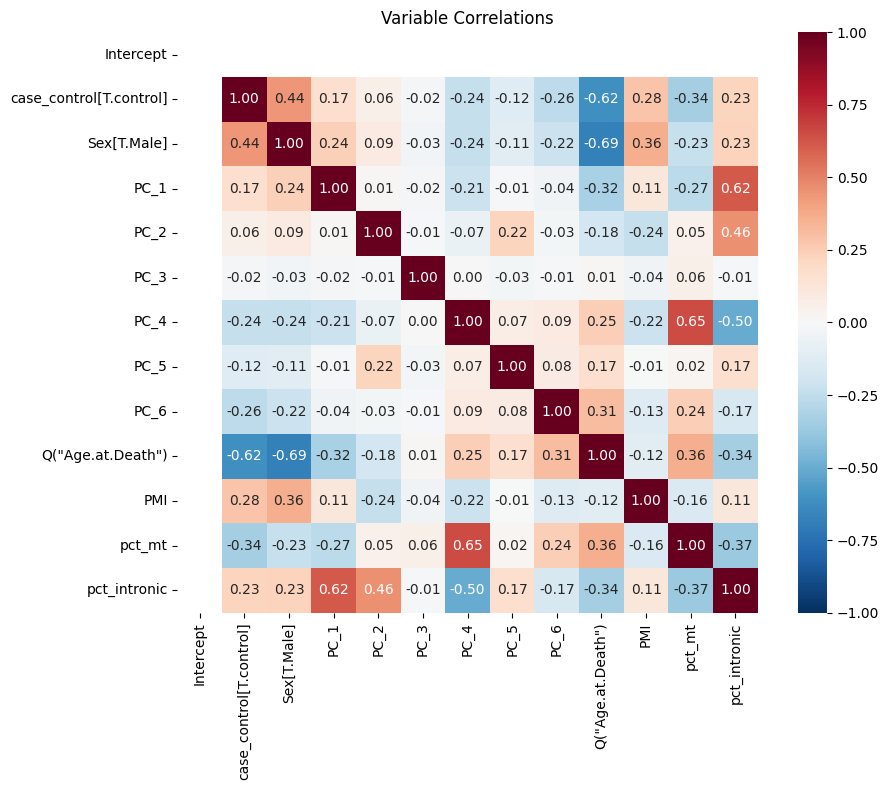

                   variable         VIF
0                 Intercept  691.557278
12             pct_intronic    3.822641
9         Q("Age.at.Death")    3.115390
6                      PC_4    2.450581
2               Sex[T.Male]    2.299493
3                      PC_1    2.273807
11                   pct_mt    2.167439
4                      PC_2    1.951667
1   case_control[T.control]    1.795695
10                      PMI    1.495011
8                      PC_6    1.215996
7                      PC_5    1.201683
5                      PC_3    1.011296

binary identifiability test. False


In [3]:
# Check collinarity
if True:
    adata_all = sc.read_h5ad(dataset_path_h5ad_0_pct_depletion)#, backed="r")
    df_combined =pd.read_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv")
    #display(df_combined)

    pcs = [i for i in adata_all.obs.columns if "PC_" in i]
    adata_all.obs = adata_all.obs.drop(columns=pcs)

    #adata_all = adata_all[adata_all.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].to_memory()

    adata_all.obs = adata_all.obs.merge(
        df_combined,
        left_index=True,
        right_on="barcode",
        how="left", 
        validate="one_to_one"
    )
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    #display(adata_all.obs[pcs])

    #adata_all.obs[[*pcs, *COVARIATES_FOR_DEG]].corr()
    DEG.check_corr_cov_in_design(adata_all, vars_in_formula=[CONTRAST_VARIABLE, *pcs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")


# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [4]:
# from statsmodels.regression.mixed_linear_model import MixedLM
# from statsmodels.stats.multitest import multipletests
# import pandas as pd
# import numpy as np

# def test_significant_pcs(df_cov, contrast_var, donor_var, pcs_vars, covs):
#     """
#     Test which PCs differ significantly between conditions.
#     Model: PC_i ~ disease_state + covariates + (1|donor)
#     """
    
#     # PREPARE DATA: Encode categorical variables ONCE before loop
#     df_model = df_cov.copy()
    
#     # # Convert categorical to numeric codes
#     # categorical_cols = df_model.select_dtypes(include=['category', 'object']).columns
#     # for col in categorical_cols:
#     #     if col != donor_var:  # Keep donor_var as category for grouping
#     #         print(f"Encoding {col}: {df_model[col].unique()} → numeric")
#     #         df_model[col] = pd.Categorical(df_model[col]).codes
#     # print(f"\nAfter encoding:")
#     # display(df_model)
#     # print(f"\nData types:")
#     # print(df_model[[contrast_var] + covs].dtypes)
    
#     results = []
    
#     for pc in pcs_vars:
#         # Build formula with quoted column names for dots
#         quoted_covs = [f'Q("{cov}")' if '.' in cov else cov for cov in covs]
#         formula = f"{pc} ~ {contrast_var} + {' + '.join(quoted_covs)}"
#         print(f"\nTesting: {formula}")
        
#         # Clean data for this PC
#         required_cols = [pc, contrast_var, donor_var] + covs
#         df_clean = df_model[required_cols].dropna()
        
#         n_dropped = len(df_model) - len(df_clean)
#         if n_dropped > 0:
#             print(f"  Dropped {n_dropped} rows with NaN")
        
#         try:
#             # Fit mixed model with better convergence settings
#             model = MixedLM.from_formula( # (Patsy) will see the strings and automatically perform Dummy Encoding (One-Hot Encoding).
#                 formula=formula,
#                 data=df_clean,
#                 groups=donor_var,  # Random effect grouping variable
#                 re_formula="1"             # Random intercept (optional, this is default)
#             )
            
#             # More robust fitting
#             result = model.fit(
#                 reml=True,
#                 method=['lbfgs'],  # Try LBFGS first
#                 maxiter=1000       # More iterations
#             )
            
#             # Extract coefficient
#             # Find the actual name statsmodels generated (e.g., case_control[T.Disease])
#             target_param = [p for p in result.params.index if contrast_var in p][0]
#             coef = result.params[target_param]
#             pval = result.pvalues[target_param]
#             stderr = result.bse[target_param]
            
#             results.append({
#                 'PC': pc,
#                 'coef': coef,
#                 'stderr': stderr,
#                 'pval': pval,
#                 'n_obs': len(df_clean),
#                 'converged': result.converged
#             })
            
#             print(f"  ✓ coef={coef:.4f}, SE={stderr:.4f}, p={pval:.4e}, converged={result.converged}")
            
#         except Exception as e:
#             # Print ACTUAL error
#             print(f"  ✗ Failed: {type(e).__name__}: {str(e)}")
#             import traceback
#             traceback.print_exc()
#             continue
    
#     df_results = pd.DataFrame(results)
    
#     # Multiple testing correction (FDR)
#     _, pvals_fdr, _, _ = multipletests(
#         df_results['pval'],
#         alpha=0.05,
#         method='fdr_bh'
#     )
#     df_results['pval_fdr'] = pvals_fdr
#     df_results['significant'] = pvals_fdr < 0.05
    
#     sig_pcs = df_results[df_results['significant']]['PC'].tolist()
    
#     print(f"\n{'='*60}")
#     print(f"RESULTS")
#     print(f"{'='*60}")
#     print(f"Tested: {len(df_results)} PCs")
#     print(f"Converged: {df_results['converged'].sum()}")
#     print(f"Significant (FDR<0.05): {len(sig_pcs)}")
#     print(f"Significant PCs: {sig_pcs}")
#     print(f"{'='*60}")
    
#     return df_results, sig_pcs

In [5]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    cov_df_csv_path = f"{results_folder_0_pct_depletion}/covariates_df.csv"
    os.makedirs(results_folder, exist_ok=True)

    ###################

    ### Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)

    # # PCs for H and D alredy caluted before
    #     # for H --> same for every geenset
    #     # for D --> changes depnding of geneset

    # # SUBSET SIGNIFICANT PCs
    # adata = sc.read_h5ad(dataset_path_h5ad)
    # df_pcs_0_pct = pd.read_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv")
    # df_pcs_0_pct = df_pcs_0_pct.merge(
    #     adata.obs[[CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, SAMPLE_VARIABLE]], 
    #     left_on="barcode", right_index=True, 
    #     how="right" # ONLY cells in current dataset
    # ).drop(columns=["barcode"])

    # display(df_pcs_0_pct)

    # #"Does this PC differ between healthy and diseased, controlling for other covariates?"
    # pcs_vars = [col for col in df_pcs_0_pct.columns.tolist() if col.startswith('PC_')]
    # df_test, pcs_sig = test_significant_pcs(
    #     df_cov=df_pcs_0_pct, 
    #     contrast_var = CONTRAST_VARIABLE,
    #     donor_var = SAMPLE_VARIABLE,
    #     pcs_vars=pcs_vars,
    #     covs = COVARIATES_FOR_DEG,
    # )

    # Save df with PCs of H+D of CURRENT dataset (ie covs to use for DEG)
        # in this case differt %depletion could differt --> so one file for ech %

    pcs_sig = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)] # NOW USE ALL

    df_pcs_all = pd.read_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv") # OF THIS SPECIFIC GENESET
    col_to_retain = ["barcode", *pcs_sig] # SELECT ONYL SIGNIFICANT PCs
    df_pcs_all = df_pcs_all[col_to_retain]
    df_pcs_all.to_csv(cov_df_csv_path, index=False)

    ##################

    # preprocessing.add_metadata_to_qs(
    #     dataset_path_h5ad, cov_df_csv_path, file_type="h5ad", 
    #     col_name_contain="PC_", barcode_col="barcode")
    preprocessing.add_metadata_to_qs(
        dataset_path_qs, cov_df_csv_path, file_type="qs", 
        col_name_contain="PC_", barcode_col="barcode")

    #break


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######



2026-02-18 17:52:44 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
[1] "Reading obj..."
[1] "Removing columns containing 'PC_': PC_1, PC_2, PC_3, PC_4, PC_5, PC_6"


2026-02-18 17:53:00 | [WARNING] R callback write-console: Loading required namespace: SeuratObject
  


[1] "Converting all columns (except barcode) to numeric..."
[1] "Saving..."


...

✓ Done!

######
 Processing dataset: depleted_0.10_dorsal_matrix 
######

Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.qs
[1] "Reading obj..."
[1] "Removing columns containing 'PC_': PC_1, PC_2, PC_3, PC_4, PC_5, PC_6"
[1] "Converting all columns (except barcode) to numeric..."
[1] "Saving..."


2026-02-18 17:58:47 | [WARNING] R callback write-console: In addition:   
2026-02-18 17:58:47 | [WARNING] R callback write-console: Warning message:
  
2026-02-18 17:58:47 | [WARNING] R callback write-console: In merge.data.frame(sc_obj@meta.data, new_meta, by.x = "row.names",  :  
2026-02-18 17:58:47 | [WARNING] R callback write-console: 
   
2026-02-18 17:58:47 | [WARNING] R callback write-console:  column name ‘Row.names’ is duplicated in the result
  


✓ Done!

######
 Processing dataset: depleted_0.00_dorsal_matrix 
######

Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.qs
[1] "Reading obj..."
[1] "Removing columns containing 'PC_': PC_1, PC_2, PC_3, PC_4, PC_5, PC_6"
[1] "Converting all columns (except barcode) to numeric..."
[1] "Saving..."


2026-02-18 17:59:42 | [WARNING] R callback write-console: In addition:   
2026-02-18 17:59:42 | [WARNING] R callback write-console: Warning message:
  
2026-02-18 17:59:42 | [WARNING] R callback write-console: In merge.data.frame(sc_obj@meta.data, new_meta, by.x = "row.names",  :  
2026-02-18 17:59:42 | [WARNING] R callback write-console: 
   
2026-02-18 17:59:42 | [WARNING] R callback write-console:  column name ‘Row.names’ is duplicated in the result
  


✓ Done!


# DEG

In [3]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    dataset="depleted_0.10_dorsal_matrix"

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    # Define PCs cov
    # ATTENTION: use all PCs
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 30, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 20, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    break

    


######
 Processing dataset: depleted_0.10_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/PCA_nebula/depleted_0.10_dorsal_matrix-PCA_nebula_results.csv
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.qs', '--id-col', 'donor_id', '--offset-col', 'nCount_RNA', '--n-folds', '30', '--n-cores', '20', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 30 --n-cores 20 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scrip

***** LOADING sobj: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.qs
Splitting 37905 genes into 30 chunks
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix__nebula_ln/chunks/chunk_001_of_030.qs (genes 1 --> 1264; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix__nebula_ln/chunks/chunk_002_of_030.qs (genes 1265 --> 2528; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix__nebula_ln/chunks/chunk_003_of_030.qs (genes 2529 --> 3792; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix__nebula_ln/

KeyboardInterrupt: 

# Plot Results

In [7]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,TTLL11,0.522222,0.3,3,"MD9129,UMBEB23076,UMBEB24013"
1,ENSG00000273797,0.100000,0.6,6,"MS30499,MS706984,MS876075,MS986638,UMBEB23076,..."
2,GLRB,-0.311111,0.8,8,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
3,ENSG00000288996,0.944444,0.6,6,"MS30499,MS706984,UMBEB22074,UMBEB23076,UMBEB23..."
4,RDH10-AS1,0.522222,0.2,2,"MS986638,UMBEB22074"
...,...,...,...,...,...
395,SP2-AS1,0.944444,0.2,2,"MS30499,UMBEB23076"
396,LRRC36,-1.366667,0.7,7,"MD9129,MS706984,MS876075,UMBEB22074,UMBEB23076..."
397,LINC00707,-1.155556,0.3,3,"MD9129,MS30499,MS706984"
398,ENSG00000288891,-1.788889,0.1,1,MS986638



######
 Processing dataset: depleted_0.80_dorsal_matrix 
######



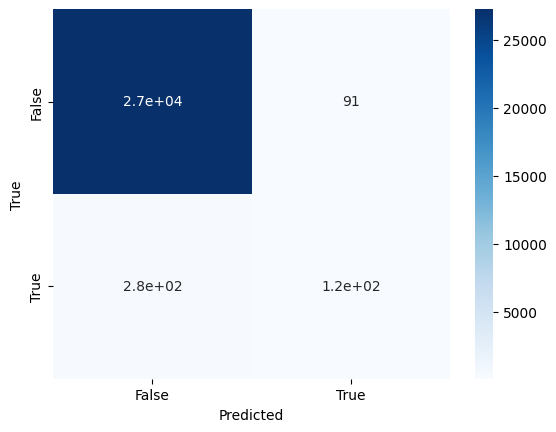

Precision: 0.558
Recall:    0.288
F1 Score:  0.380
Accuracy:  0.986
Clipping 22 genes with -log10(p) > 10


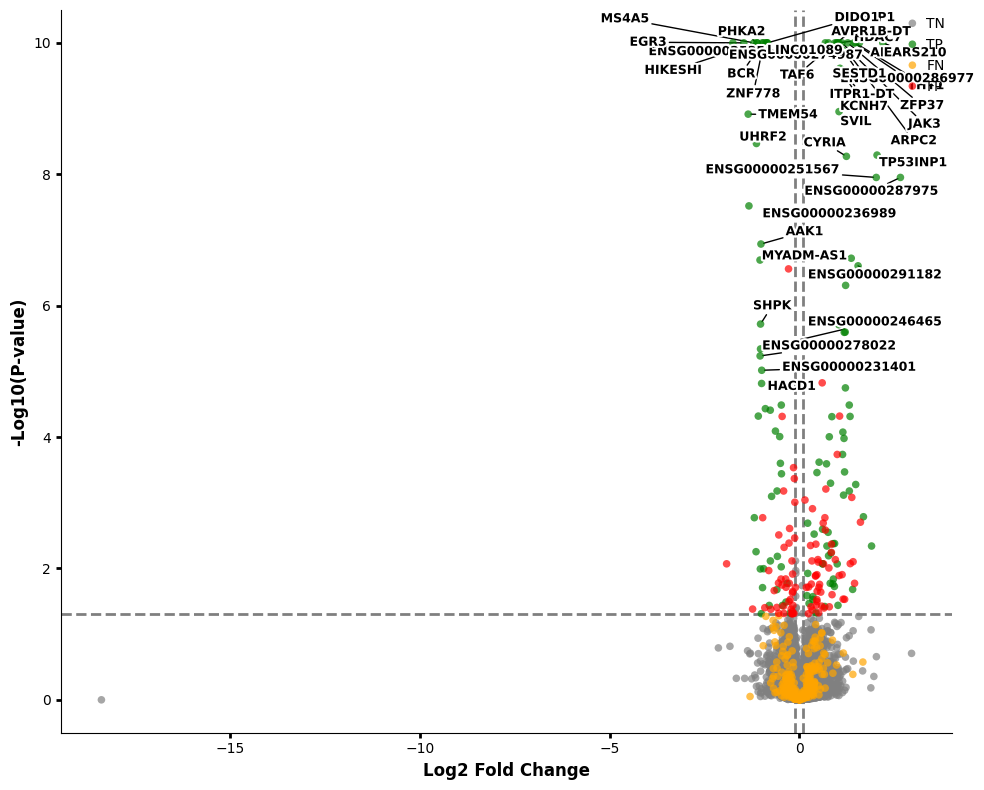

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.048574,0.256022,0.841266,False,False,0.075067,TN,-3.646270e-03
1,A1BG-AS1,-0.058478,0.427668,0.904872,False,False,0.043413,TN,-2.538693e-03
2,A1CF,-0.112279,0.468491,0.915137,False,False,0.038514,TN,-4.324318e-03
3,A2M,0.411854,0.052100,0.574273,False,False,0.240882,TN,9.920815e-02
4,A2M-AS1,0.016214,0.807286,0.975327,False,False,0.010850,TN,1.759158e-04
...,...,...,...,...,...,...,...,...,...
27723,ZZEF1,-0.000093,0.997354,0.999434,False,False,0.000246,TN,-2.285254e-08
27724,ZZZ3,0.049840,0.207451,0.812001,False,False,0.090444,TN,4.507680e-03
27725,ENSG00000205653,0.343435,0.644897,0.951858,False,False,0.021428,TN,7.359123e-03
27726,ENSG00000223438,0.081101,0.883614,0.982699,False,False,0.007580,TN,6.147030e-04


In [8]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break